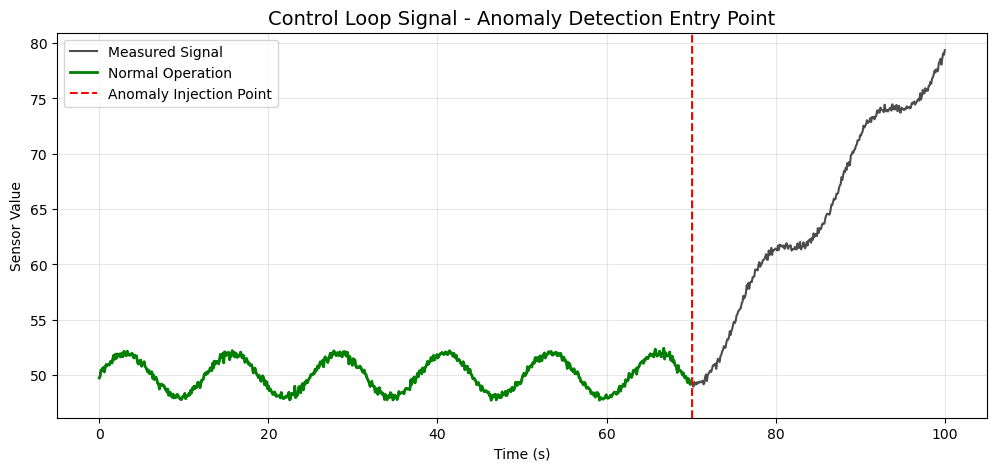

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Simulate a normal control signal (e.g., Temperature in a PID loop)
t = np.linspace(0, 100, 1000)
normal_signal = 50 + 2 * np.sin(0.5 * t) + np.random.normal(0, 0.2, 1000)

# 2. Inject an anomaly (Sudden sensor drift starting at t=700)
anomaly_signal = normal_signal.copy()
anomaly_signal[700:] = anomaly_signal[700:] + 0.1 * (np.arange(300)) # Linear drift

# 3. Visualization for FDI (Fault Detection & Isolation)
plt.figure(figsize=(12, 5))
plt.plot(t, anomaly_signal, label='Measured Signal', color='black', alpha=0.7)
plt.plot(t[:700], normal_signal[:700], label='Normal Operation', color='green', lw=2)
plt.axvline(x=t[700], color='red', linestyle='--', label='Anomaly Injection Point')

plt.title('Control Loop Signal - Anomaly Detection Entry Point', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Sensor Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [2]:
import os

# Create data directory if it doesn't exist
data_dir = 'data'
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

# Download a sample CSV from the SKAB dataset (Valve fault scenario)
url = "https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/machine_temperature_system_failure.csv"
output_path = os.path.join(data_dir, 'industrial_sensor_data.csv')

if not os.path.exists(output_path):
    import urllib.request
    urllib.request.urlretrieve(url, output_path)
    print(f"[INFO] Real-world dataset downloaded: {output_path}")
else:
    print("[INFO] Dataset already exists.")

    

[INFO] Dataset already exists.


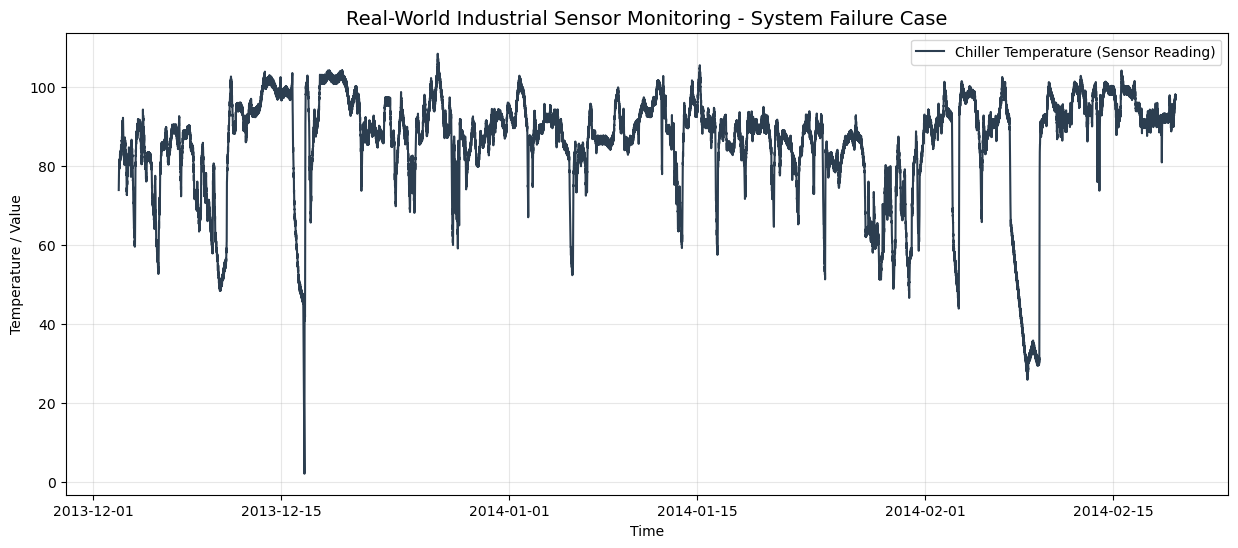

Dataset summary:
              value
count  22695.000000
mean      85.926498
std       13.746912
min        2.084721
25%       83.080078
50%       89.408246
75%       94.016252
max      108.510543


In [3]:
# Load the real dataset
df_real = pd.read_csv(output_path, parse_dates=['timestamp'], index_col='timestamp')

# Plotting the real industrial sensor data
plt.figure(figsize=(15, 6))
plt.plot(df_real['value'], color='#2c3e50', label='Chiller Temperature (Sensor Reading)')
plt.title('Real-World Industrial Sensor Monitoring - System Failure Case', fontsize=14)
plt.ylabel('Temperature / Value')
plt.xlabel('Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Dataset summary:\n{df_real.describe()}")

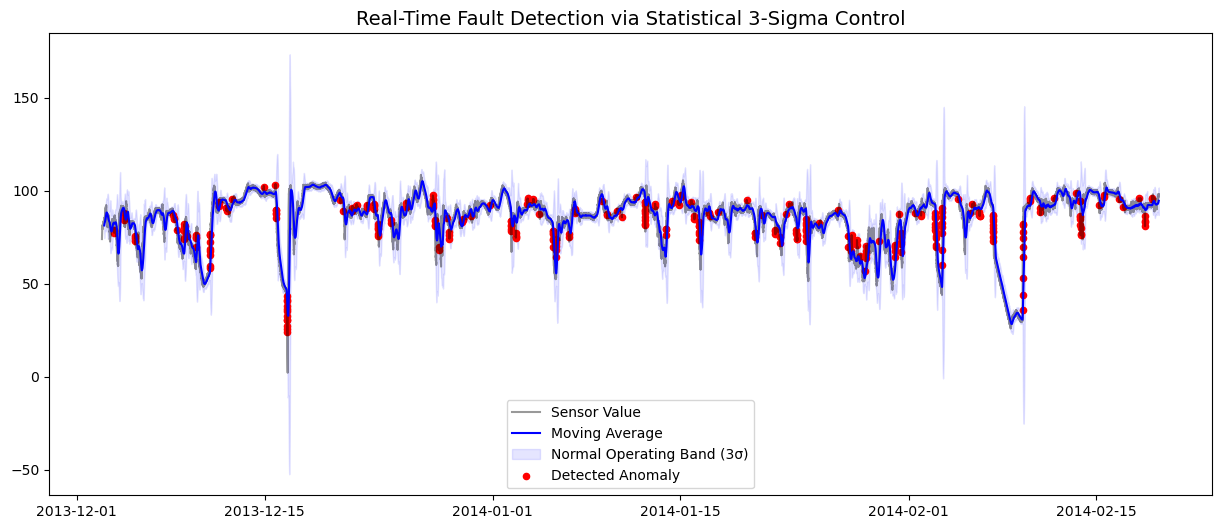

In [4]:
# Calculate moving average and moving standard deviation
window = 50
df_real['mean'] = df_real['value'].rolling(window=window).mean()
df_real['std'] = df_real['value'].rolling(window=window).std()

# Define anomaly threshold (3 Sigma Rule)
df_real['upper_limit'] = df_real['mean'] + (3 * df_real['std'])
df_real['lower_limit'] = df_real['mean'] - (3 * df_real['std'])

# Mark anomalies where value is outside 3rd sigma
df_real['anomaly'] = ((df_real['value'] > df_real['upper_limit']) | 
                      (df_real['value'] < df_real['lower_limit']))

# Visualize detection
plt.figure(figsize=(15, 6))
plt.plot(df_real['value'], color='black', alpha=0.4, label='Sensor Value')
plt.plot(df_real['mean'], color='blue', label='Moving Average')
plt.fill_between(df_real.index, df_real['lower_limit'], df_real['upper_limit'], 
                 color='blue', alpha=0.1, label='Normal Operating Band (3σ)')

# Highlight detected anomalies
anomalies = df_real[df_real['anomaly'] == True]
plt.scatter(anomalies.index, anomalies['value'], color='red', s=20, label='Detected Anomaly')

plt.title('Real-Time Fault Detection via Statistical 3-Sigma Control', fontsize=14)
plt.legend()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

# 1. Data Preparation
scaler = StandardScaler()
# Using the same df_real from previous cells
data_tensor = torch.FloatTensor(scaler.fit_transform(df_real[['value']].values))

# 2. Define the Autoencoder Architecture (PyTorch Style)
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self). __init__()
        self.encoder = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 4) # Bottleneck
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# 3. Model Training
model = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print("Starting AI Training with PyTorch...")
for epoch in range(50):
    optimizer.zero_grad()
    outputs = model(data_tensor)
    loss = criterion(outputs, data_tensor)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/50], Loss: {loss.item():.4f}')

# 4. Anomaly Detection
model.eval()
with torch.no_grad():
    reconstructed = model(data_tensor)
    # Calculate Reconstruction Error (MAE)
    error = torch.abs(reconstructed - data_tensor).numpy()

df_real['reconstruction_error'] = error
threshold = df_real['reconstruction_error'].mean() + 3 * df_real['reconstruction_error'].std()
df_real['ai_anomaly'] = df_real['reconstruction_error'] > threshold

print(f"\n[SUCCESS] AI Anomaly Detection complete. Threshold: {threshold:.4f}")



Starting AI Training with PyTorch...
Epoch [10/50], Loss: 0.2107
Epoch [20/50], Loss: 0.0787
Epoch [30/50], Loss: 0.0305
Epoch [40/50], Loss: 0.0057
Epoch [50/50], Loss: 0.0018

[SUCCESS] AI Anomaly Detection complete. Threshold: 0.1462


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

# 1. Data Preparation
scaler = StandardScaler()
# Using the same df_real from previous cells
data_tensor = torch.FloatTensor(scaler.fit_transform(df_real[['value']].values))

# 2. Define the Autoencoder Architecture (PyTorch Style)
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self). __init__()
        self.encoder = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 4) # Bottleneck
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# 3. Model Training
model = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print("Starting AI Training with PyTorch...")
for epoch in range(50):
    optimizer.zero_grad()
    outputs = model(data_tensor)
    loss = criterion(outputs, data_tensor)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/50], Loss: {loss.item():.4f}')

# 4. Anomaly Detection
model.eval()
with torch.no_grad():
    reconstructed = model(data_tensor)
    # Calculate Reconstruction Error (MAE)
    error = torch.abs(reconstructed - data_tensor).numpy()

df_real['reconstruction_error'] = error
threshold = df_real['reconstruction_error'].mean() + 3 * df_real['reconstruction_error'].std()
df_real['ai_anomaly'] = df_real['reconstruction_error'] > threshold

print(f"\n[SUCCESS] AI Anomaly Detection complete. Threshold: {threshold:.4f}")

Starting AI Training with PyTorch...
Epoch [10/50], Loss: 0.3103
Epoch [20/50], Loss: 0.0932
Epoch [30/50], Loss: 0.0503
Epoch [40/50], Loss: 0.0085
Epoch [50/50], Loss: 0.0063

[SUCCESS] AI Anomaly Detection complete. Threshold: 0.1979


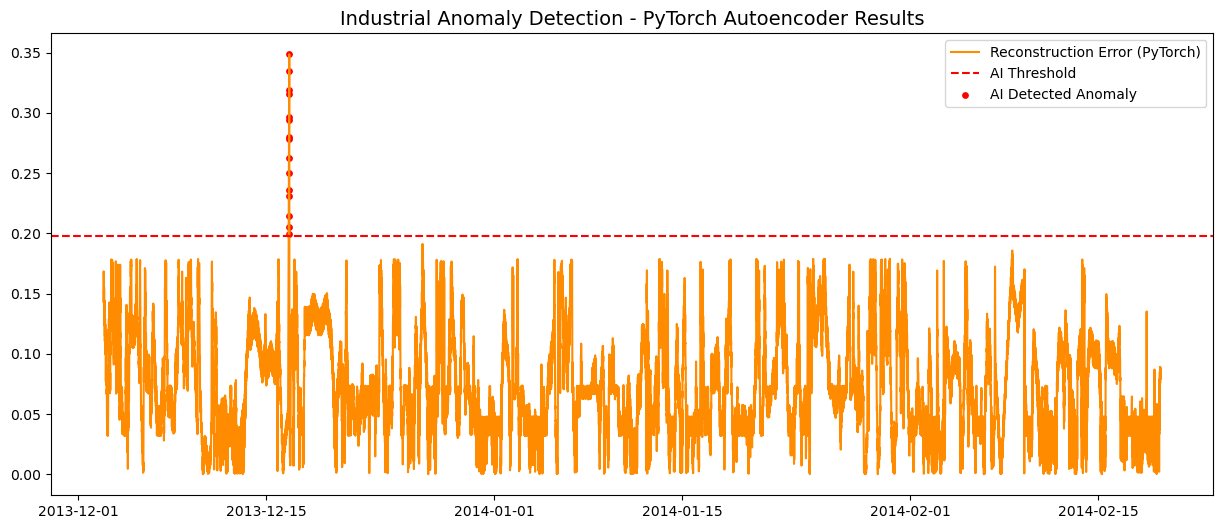

In [7]:
plt.figure(figsize=(15, 6))
plt.plot(df_real.index, df_real['reconstruction_error'], color='darkorange', label='Reconstruction Error (PyTorch)')
plt.axhline(y=threshold, color='red', linestyle='--', label='AI Threshold')

# Spot the anomalies
anomalies_ai = df_real[df_real['ai_anomaly']]
plt.scatter(anomalies_ai.index, anomalies_ai['reconstruction_error'], color='red', s=15, label='AI Detected Anomaly')

plt.title('Industrial Anomaly Detection - PyTorch Autoencoder Results', fontsize=14)
plt.legend()
plt.show()